# Lattice model: MF vs MCMC



In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

from Bio import SeqIO
from tqdm import tqdm
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
from adjustText import adjust_text
from matplotlib.patches import Circle
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.patches import Polygon
import math
from matplotlib.patches import Ellipse, Patch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import random




main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "mean_field_theory/")
from utils_mean_field import *
from script_mean_field_covid import *
os.chdir('../lattice')



e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

In [2]:
PROTEIN_INIT = Proteins_utils.load_FASTA(
        "../lattice/msa/output_msa_structure_0_beta_1000.fasta"
    )[0]  
POS_CHARGE = {"K", "R", "H"}
NEG_CHARGE = {"D", "E"}
sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
print("sites upper face", sites)
w_bias = np.zeros((PROTEIN_INIT.shape[0], 20, 1))
for site in sites:
    wt_idx = PROTEIN_INIT[site]  
    wt_char = CODE_RBM[wt_idx] 

    for i in range(20):
        mut_char = CODE_RBM[i]  

        wt_is_pos = wt_char in POS_CHARGE
        wt_is_neg = wt_char in NEG_CHARGE
        mut_is_pos = mut_char in POS_CHARGE
        mut_is_neg = mut_char in NEG_CHARGE

        is_charge_flip = (wt_is_pos and mut_is_neg) or (wt_is_neg and mut_is_pos)

        if i != wt_idx and is_charge_flip:
            w_bias[site, i, 0] = 1
        

sites upper face [ 8  9 10 11 12 15 16 24 25]


In [3]:
RBM = RBM_utils.loadRBM("rbm/RBM_structure_0_beta_100")

wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
wgamma = np.concatenate((wgamma, w_bias), axis=2)

wgamma.shape#L, Q, M
wgamma_flat= wgamma.reshape(wgamma.shape[0]*wgamma.shape[1], wgamma.shape[2]).T

wgamma_flat.shape

(21, 540)

# Get order parameters

In [4]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    

    assert D == D2
    
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    for k in range(K):
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


# Get MCMC paths

In [5]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    print("proj_mat", proj_mat.shape)
    return proj_mat



In [6]:

seqs=Proteins_utils.load_FASTA('../lattice/msa/output_msa_structure_0_beta_1000.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])

one_hot_seqs.shape

(199, 540)

# Project




In [7]:
L=27
beta_w=10

folder='../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_'+str(beta_w)
mopt = -np.load(f"{folder}/mopt.npy")
mopt.shape#(T, M) path of T steps and M hidden units
var = np.var(mopt[:,:-1], axis=0)
idx = np.argsort(var)[:]
idx=np.array([mopt.shape[1]-1,idx[-1]])
mopt_2d = mopt[:, idx]
print("idx", idx)

dir_mcmc = f"../lattice/paths/w_upper_T10_beta_ab_{beta_w}"
paths_mcmc=-get_mcmc_proba_aa(dir_mcmc, wgamma_flat)
paths_mcmc.shape#(num_paths, T, M)

idx [20  4]
proj_mat (100, 11, 21)


(100, 11, 21)

explained variance ratio [0.87618872 0.11000599]
random_idxs [49, 97, 53, 5, 33, 65, 62, 51, 38, 61]


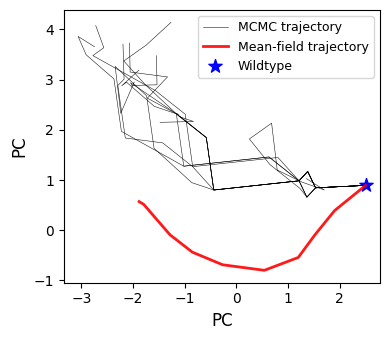

In [8]:
def project_and_plot_2d():

    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    pca.fit(mopt)  
    print("explained variance ratio", pca.explained_variance_ratio_)
    mopt_2d = pca.transform(mopt)
    paths_mcmc_2d = pca.transform(paths_mcmc.reshape(-1, paths_mcmc.shape[2])).reshape(paths_mcmc.shape[0], paths_mcmc.shape[1], 2)
    random.seed(0)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 10)
    print("random_idxs", random_idxs)
    paths_mcmc_2d = paths_mcmc_2d[random_idxs]


    wt_2d = paths_mcmc_2d[0]

    fig, ax = plt.subplots(figsize=(4, 3.5))

  
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)
        
    ax.plot(mopt_2d[:,0], mopt_2d[:,1],
            color='red', linewidth=2, alpha=0.9,
            label="Mean-field trajectory")


    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')

    ax.set_ylabel("PC", fontsize=12)
    ax.set_xlabel("PC", fontsize=12)



    ax.legend(loc='best', frameon=True, fontsize=9)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


random_idxs [17, 72, 97, 8, 32, 15, 63, 57, 60, 83, 48, 26, 12, 62, 3, 49, 55, 77, 98, 0]


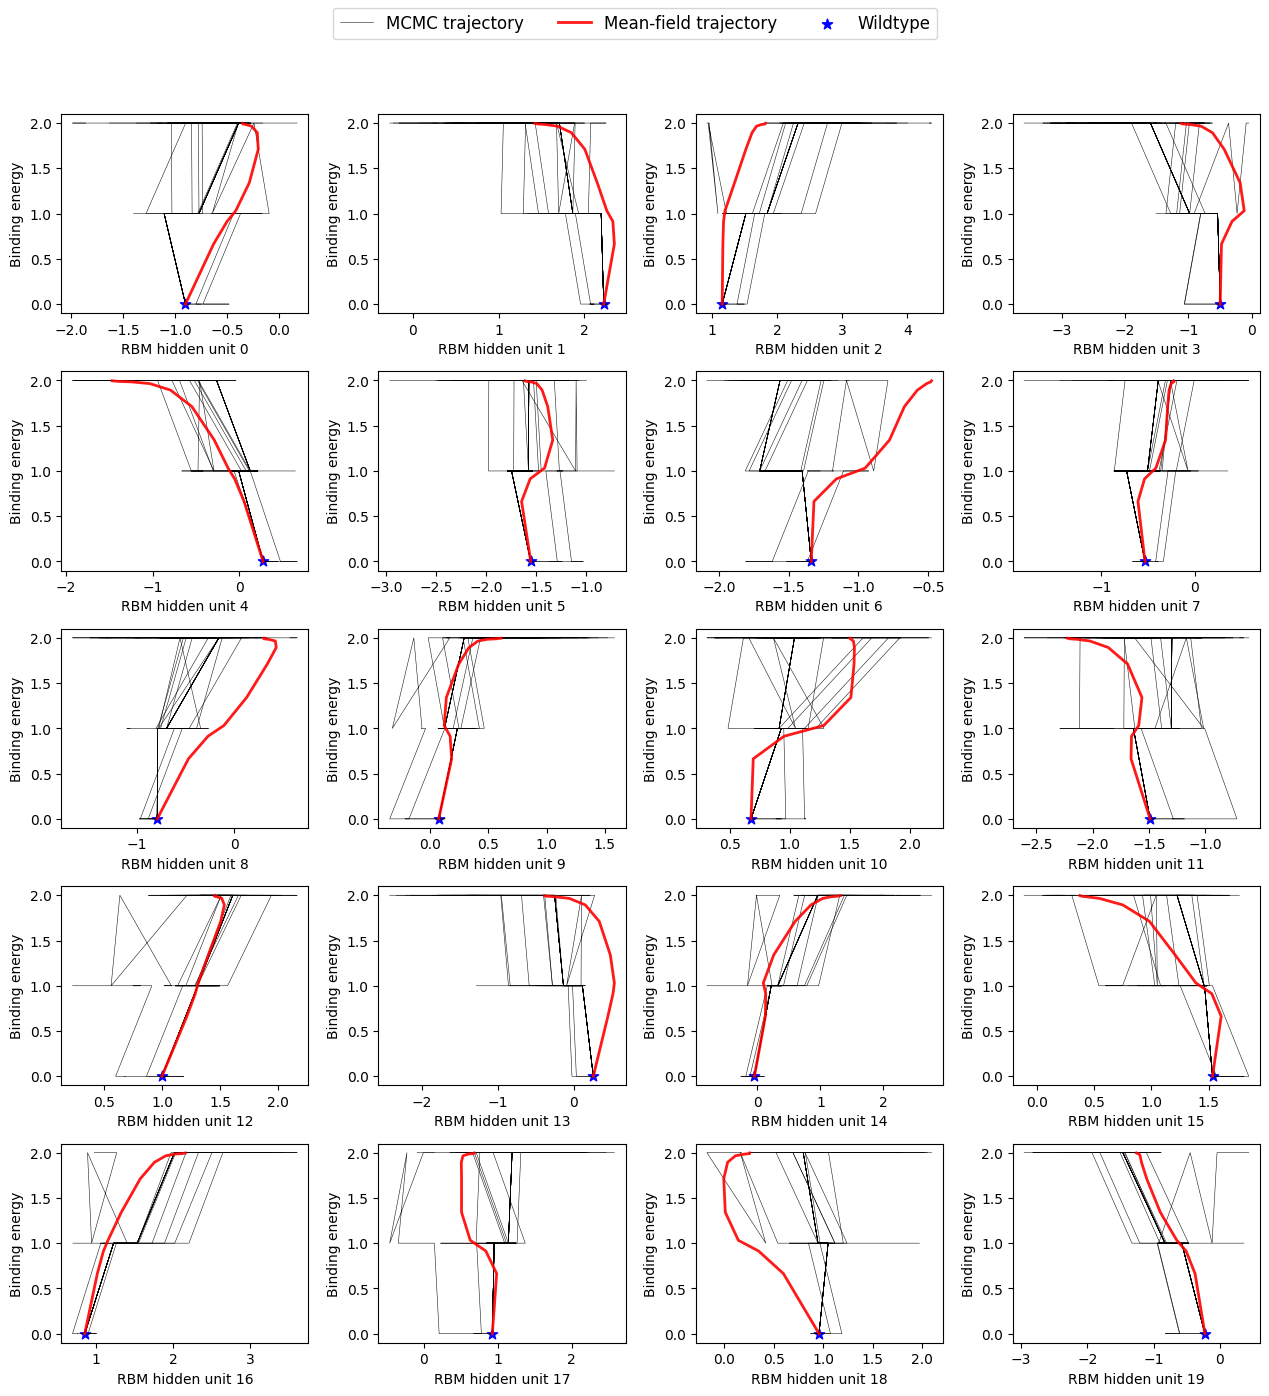

In [9]:


def project_and_plot_2d(n_random_paths=20, seed=0, ncols=4, js=None):
    """
    Plots subplots for each j in js:
      x-axis = coordinate j
      y-axis = last coordinate (index D-1)
    Expects global arrays:
      - mopt:          shape (T+1, D)
      - paths_mcmc:    shape (N_paths, T+1, D)
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T,D), paths_mcmc (N,T,D)"
    T, D = mopt.shape
    last_idx = D - 1
    if js is None:
        js = [j for j in range(D) if j != last_idx]  # all except last

    random.seed(seed)
    N = paths_mcmc.shape[0]
    n_pick = min(n_random_paths, N)
    random_idxs = random.sample(range(N), n_pick)
    print("random_idxs", random_idxs)

    wt = paths_mcmc[random_idxs[0], 0]  # shape (D,)

    nplots = len(js)
    nrows = math.ceil(nplots / ncols)
    figsize = (3.2 * ncols, 2.8 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    handled_legend = False

    for k, j in enumerate(js):
        ax = axes[k]

        for i, pidx in enumerate(random_idxs):
            path = paths_mcmc[pidx]  # (T+1, D)
            lbl = "MCMC trajectory" if (i == 0 and not handled_legend) else None
            ax.plot(path[:, j], -path[:, last_idx],
                    color='black', linewidth=0.4, alpha=0.9, label=lbl)

        lbl = "Mean-field trajectory" if not handled_legend else None
        ax.plot(mopt[:, j], -mopt[:, last_idx],
                color='red', linewidth=2, alpha=0.9, label=lbl)

        lbl = "Wildtype" if not handled_legend else None
        ax.scatter(wt[j], -wt[last_idx], color='blue', marker='*', s=60, label=lbl)

        ax.set_xlabel(f"RBM hidden unit {j}")
        ax.set_ylabel("Binding energy")

        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)

        if not handled_legend:
            handled_legend = True

    for k in range(nplots, len(axes)):
        axes[k].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize=12)

    plt.tight_layout(rect=(0, 0, 1, 0.93)) 
    plt.show()

project_and_plot_2d(seed=1)


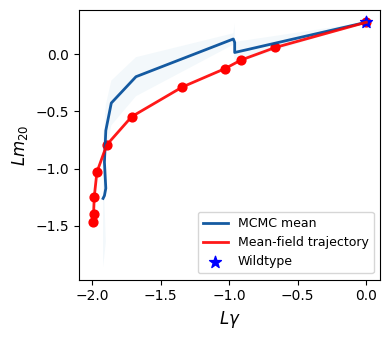

In [10]:


def _make_band_polygon(xs_lower, ys_lower, xs_upper, ys_upper):
    """
    Build a closed polygon between two parametric curves:
      lower: (xs_lower[t], ys_lower[t])
      upper: (xs_upper[t], ys_upper[t])
    Curves are connected forward for lower and backward for upper.
    """
    pts_lower = np.column_stack([xs_lower, ys_lower])          
    pts_upper = np.column_stack([xs_upper, ys_upper])[::-1, :] 
    pts = np.vstack([pts_lower, pts_upper])
    return Polygon(pts, closed=True, linewidth=0)

def project_and_plot_2d(*, band_alpha_xy=(0.18, 0.12),
                        band_color_x="#3182bd", band_color_y="#9ecae1",
                        mean_color="#08519c", mean_lw=2.0):
    """
    Plot 2D mean MCMC trajectory with shaded m±std ribbons
    (component-wise) and the provided mean-field trajectory mopt_2d.

    Expected globals:
        - paths_mcmc: list of arrays with shape (T, S), we use [:, idx] -> (T,2)
        - mopt_2d: array (T,2)
        - idx: tuple/list of two indices selecting the 2D projection
    """

    paths_mcmc_2d = [p[:, idx] for p in paths_mcmc]  
    assert len(paths_mcmc_2d) > 0, "No MCMC paths."
    P = np.stack(paths_mcmc_2d, axis=0)              
    N, T, _ = P.shape

    mean_path = P.mean(axis=0)                      
    std_path  = P.std(axis=0, ddof=1 if N > 1 else 0)  

    mx, my = mean_path[:, 0], mean_path[:, 1]
    sx, sy = std_path[:, 0],  std_path[:, 1]

 
    poly_y = _make_band_polygon(
        xs_lower=mx, ys_lower=my - sy,
        xs_upper=mx, ys_upper=my + sy
    )

    poly_x = _make_band_polygon(
        xs_lower=mx - sx, ys_lower=my,
        xs_upper=mx + sx, ys_upper=my
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    poly_y.set_facecolor(band_color_y)
    poly_y.set_alpha(band_alpha_xy[1])
    ax.add_patch(poly_y)

    poly_x.set_facecolor(band_color_x)
    poly_x.set_alpha(band_alpha_xy[0])

    ax.plot(mx, my, color=mean_color, linewidth=mean_lw, alpha=0.95, label="MCMC mean")

    ax.plot(mopt_2d[:, 0], mopt_2d[:, 1],
            color='red', linewidth=2.0, alpha=0.9,
            label="Mean-field trajectory")
    ax.scatter(mopt_2d[:, 0], mopt_2d[:, 1], color='red', marker='o', s=40)  # start

    wt_2d = P[0, 0, :]
    ax.scatter(wt_2d[0], wt_2d[1], color='blue', marker='*', s=80, label='Wildtype')

    ax.set_ylabel(r"$L m_{" + str(idx[0]) + "}$", fontsize=12)
    ax.set_xlabel(r"$L \gamma$", fontsize=12)

    ax.legend(loc='best', frameon=True, fontsize=9)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


In [11]:
path_proba = '../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_10.npy'
probas = np.load(path_proba)  
probas = np.round(probas, 6)  
probas.shape#Q,T,L


(20, 11, 27)

In [12]:


def analyze_probabilities(path_proba=path_proba, threshold=0.1):
    if path_proba and os.path.exists(path_proba):
        print(f"Loading data from {path_proba}...")
        probas = np.load(path_proba)
    
    probas = np.round(probas, 6)
    Q, T, L = probas.shape
    print(f"Data Shape: Q={Q}, T={T}, L={L}")

  
    wt_sequence = np.argmax(probas[:, 0, :], axis=0)
    print(f"WT Sequence (Indices): {wt_sequence}")


    print(f"\n--- Scanning for Multi-Mutant signatures (TH={threshold}) ---")
    
    detected_steps = []
    
    for t in range(T):

        above_th_mask = probas[:, t, :] > threshold
        

        for l in range(L):
            wt_aa = wt_sequence[l]
            above_th_mask[wt_aa, l] = False
            
  
        concurrent_mutants_per_site = np.sum(above_th_mask, axis=0) # Shape (L,)
        
        bifurcating_sites = np.where(concurrent_mutants_per_site >= 2)[0]
        
        if len(bifurcating_sites) > 0:
            detected_steps.append(t)
            print(f"[Step {t}] FOUND condition!")
            for l in bifurcating_sites:
                mutant_indices = np.where(above_th_mask[:, l])[0]
                mutant_probs = probas[mutant_indices, t, l]
                wt_idx = wt_sequence[l]
                wt_prob = probas[wt_idx, t, l]
                
                print(f"  -> Site {l}: WT(aa={wt_idx}) p={wt_prob:.4f}")
                print(f"     Competing Non-WTs: {list(zip(mutant_indices, mutant_probs))}")

    if not detected_steps:
        print("No steps found where a site has >= 2 non-WT amino acids above threshold.")

    return probas

if __name__ == "__main__":
 
    analyze_probabilities(path_proba, threshold=0.1)

Loading data from ../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_10.npy...
Data Shape: Q=20, T=11, L=27
WT Sequence (Indices): [ 8  1  1  1  1  3  5 17  2  3 19 13  5  1  9 12  8 17  6  1  9  7  1  2
  8  8  9]

--- Scanning for Multi-Mutant signatures (TH=0.1) ---
[Step 6] FOUND condition!
  -> Site 4: WT(aa=1) p=0.4206
     Competing Non-WTs: [(4, 0.210958), (10, 0.274963)]
[Step 7] FOUND condition!
  -> Site 2: WT(aa=1) p=0.3484
     Competing Non-WTs: [(2, 0.48399), (3, 0.166709)]
  -> Site 4: WT(aa=1) p=0.1686
     Competing Non-WTs: [(4, 0.303158), (7, 0.117779), (10, 0.386029)]
[Step 8] FOUND condition!
  -> Site 2: WT(aa=1) p=0.1239
     Competing Non-WTs: [(2, 0.636202), (3, 0.236437)]
  -> Site 4: WT(aa=1) p=0.0393
     Competing Non-WTs: [(4, 0.349228), (7, 0.141081), (10, 0.438857)]
[Step 9] FOUND condition!
  -> Site 2: WT(aa=1) p=0.0475
     Competing Non-WTs: [(2, 0.681296), (3, 0.262994)]
  -> Site 4: WT(aa=1) p=0.0079
     Competing Non-WTs: [(

In [13]:

probas=np.load(path_proba)  # shape: (amino_acid, step, site)
probas = probas / probas.sum(axis=0, keepdims=True)


C:\Users\maria\AppData\Local\Temp\ipykernel_25768\2787661146.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


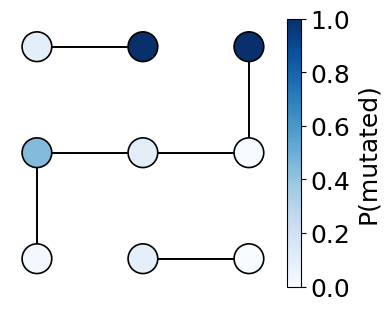

In [14]:


CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
aa_to_idx = {a:i for i,a in enumerate(CODE_RBM)}

LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),       
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          
    (9, 10),        
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx = np.array(EPITOPE_SITES) - 1  

def mutation_probabilities(
    probas: np.ndarray,               
    wt_letters: dict[int, str] | None = None  
) -> np.ndarray:
    """
    Returns P(mutated) with shape (T, S):
    mutated means amino acid != reference aa at the first step.
    Reference aa per site:
      - if wt_letters provided, use it
      - else: argmax over amino acids at step 0
    """
    denom = probas.sum(axis=0, keepdims=True)    # (1, T, S)
    denom = np.where(denom == 0.0, 1.0, denom)
    p = probas / denom                           # (A, T, S)

    A, T, S = p.shape

    ref_idx = np.empty(S, dtype=int)

    if wt_letters is not None:
        for s0 in range(S):
            site_1b = s0 + 1
            if site_1b in wt_letters:
                ref_idx[s0] = aa_to_idx[wt_letters[site_1b]]
            else:
                ref_idx[s0] = int(np.argmax(p[:, 0, s0]))
    else:
        ref_idx = np.argmax(p[:, 0, :], axis=0)  # (S,)

  
    row = ref_idx[np.newaxis, :]                 # (1, S)
    col = np.arange(S)[np.newaxis, :]            # (1, S)
    p_ref = p[row, np.arange(T)[:, None], col]   # (T, S)
    p_mut = 1.0 - p_ref
    return p_mut

def draw_epitope_scalar(
    ax,
    centre=(0.0, 0.0),
    value_map=None,         
    edge_colour="black",
    scale=0.35,
    radius=0.14,
    z=3,
    cmap_name="Blues",
    norm=None
):
    """
    Draw 3×3 epitope: bonds + circles colored by provided scalar (no letters).
    """
    cx, cy = centre
    cmap = get_cmap(cmap_name)
    if norm is None:
        vmax = max(value_map.values()) if value_map else 1.0
        norm = Normalize(vmin=0.0, vmax=vmax)

    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot(
            [cx + scale*xa, cx + scale*xb],
            [cy + scale*ya, cy + scale*yb],
            lw=1.4, color=edge_colour, zorder=z
        )

    for site, (dx, dy) in LATTICE.items():
        v = value_map.get(site, 0.0)
        face = cmap(norm(v))
        circ = Circle(
            (cx + scale*dx, cy + scale*dy),
            radius*scale,
            facecolor=face,
            edgecolor=edge_colour,
            lw=1.2,
            zorder=z+1
        )
        ax.add_patch(circ)

    return norm, cmap

def plot_epitope_pmut(
    probas: np.ndarray,            # (A, T, S)
    step: int,
    wt_letters: dict[int, str] | None = None,  
    cmap_name: str = "Blues"
    #
):
    """
    Plot epitope colored by P(mutated) at a given step.
    If wt_letters is None, reference aa at each site is argmax at step 0.
    """
    p_mut = mutation_probabilities(probas, wt_letters=wt_letters)  # (T, S)

    vals = p_mut[step, sites_idx]                 # shape (9,)
    value_map = {site: v for site, v in zip(EPITOPE_SITES, vals)}

    fig, ax = plt.subplots(figsize=(4, 4))
    norm = Normalize(vmin=0.0, vmax=1.0)         # probability in [0, 1]
    norm, cmap = draw_epitope_scalar(
        ax,
        centre=(0.0, 0.0),
        value_map=value_map,
        edge_colour="black",
        scale=0.35,
        radius=0.14,
        z=3,
        cmap_name=cmap_name,
        norm=norm
    )

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(mutated)", fontsize=18)
    cbar.ax.tick_params(labelsize=18)           # bigger tick numbers
    ax.set_aspect("equal")
    ax.axis("off")
    # ax.set_title("Mean field")

    plt.tight_layout()
    return fig, ax

fig, ax = plot_epitope_pmut(probas, step=-1)



# Comparison with MCMC

In [15]:



paths_nb = 100
beta_lattice = 1000
beta_w = 10
dir_in = f"paths/w_upper_T10_beta_ab_{beta_w}/"

alphabet = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(alphabet)}
idx_to_aa = {i: aa for i, aa in enumerate(alphabet)}
A_len = len(alphabet)

def seq_to_indices(seq):
    """Converts a string sequence to a numpy array of indices."""
    return np.array([aa_to_idx.get(s, 0) for s in seq], dtype=int)



all_path_indices = [] 
wt_seq_str = None    

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    if wt_seq_str is None:
        wt_seq_str = str(seqs[0].seq)

    path_int_seqs = np.array([seq_to_indices(str(r.seq)) for r in seqs])
    
    all_path_indices.append(path_int_seqs)

if len(all_path_indices) == 0:
    raise RuntimeError("No valid paths loaded.")


min_T = min(arr.shape[0] for arr in all_path_indices)
S_len = all_path_indices[0].shape[1]

print(f"Aggregating over {len(all_path_indices)} paths.")
print(f"Dimensions: A={A_len}, T={min_T}, S={S_len}")
counts_tensor = np.zeros((A_len, min_T, S_len), dtype=np.float32)

for path_arr in all_path_indices:
  
    truncated = path_arr[:min_T, :]
    

    one_hot = np.eye(A_len)[truncated] # (min_T, S, A)
    
    counts_tensor += one_hot.transpose(2, 0, 1)

probas_mcmc = counts_tensor / counts_tensor.sum(axis=0, keepdims=True)




Reading β_w=10: 100%|██████████| 100/100 [00:00<00:00, 539.34it/s]

Aggregating over 100 paths.
Dimensions: A=20, T=11, S=27


C:\Users\maria\AppData\Local\Temp\ipykernel_25768\2787661146.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


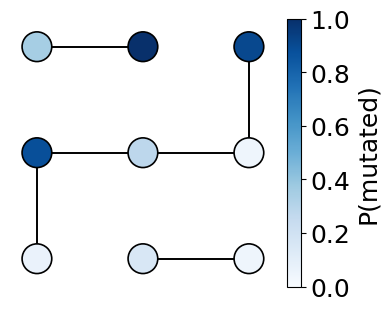

In [16]:
fig, ax = plot_epitope_pmut(probas_mcmc, step=-1)


In [17]:
mutation_probas_mcmc=mutation_probabilities(probas_mcmc)  
mutation_probabilities_mf=mutation_probabilities(probas)  




Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


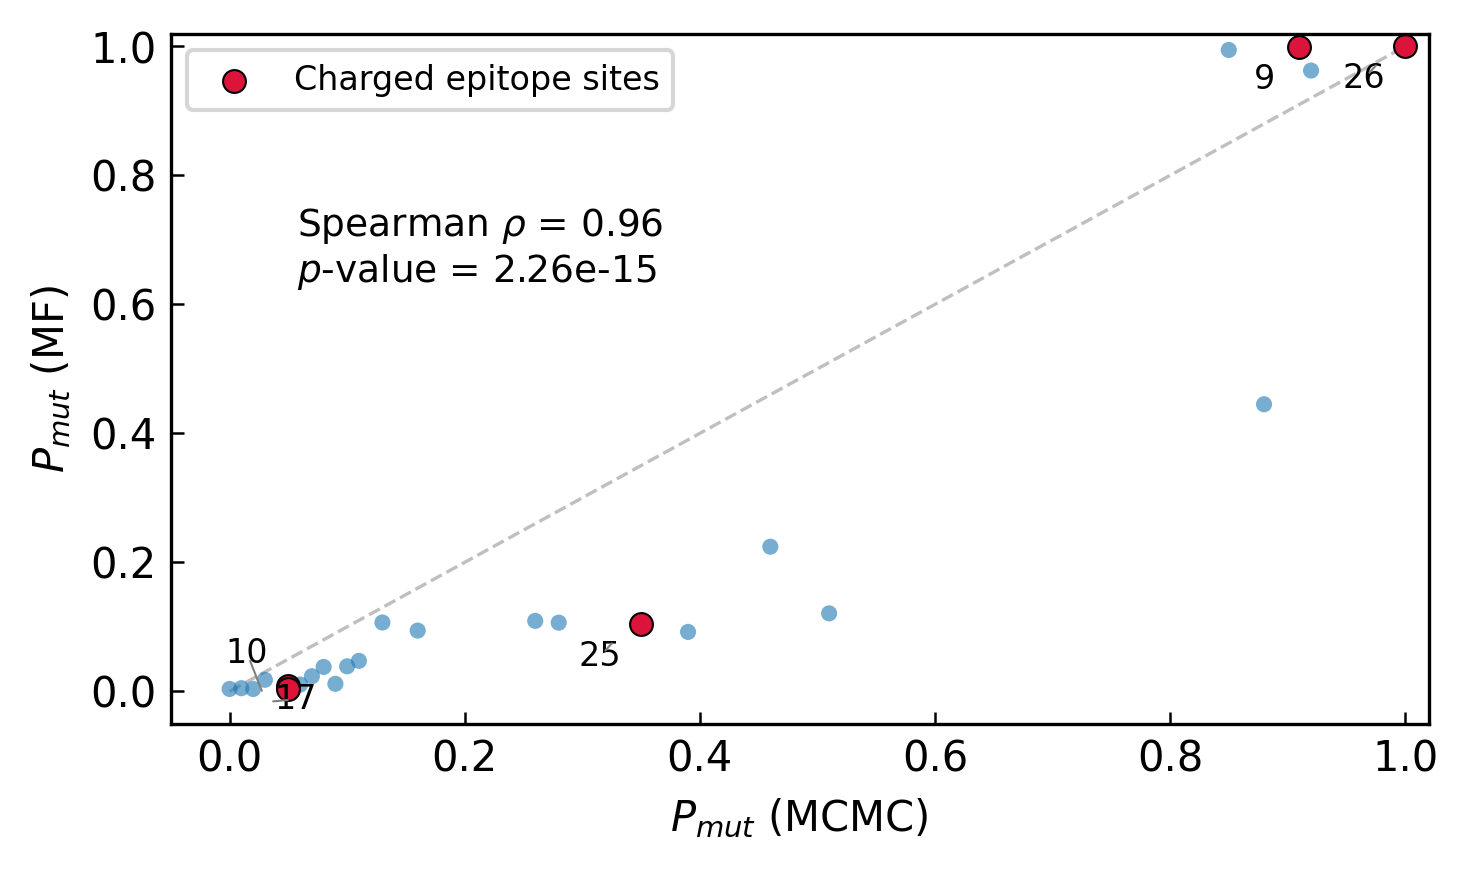

In [18]:

x_data = mutation_probas_mcmc[-1, :]
y_data = mutation_probabilities_mf[-1, :]

target_indices = np.array([25, 26, 9,10,17] )-1

all_indices = np.arange(len(x_data))
mask_targets = np.isin(all_indices, target_indices)

rho, p_val = spearmanr(x_data, y_data)

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

ax.scatter(
    x_data[~mask_targets], 
    y_data[~mask_targets], 
    color='tab:blue', 
    alpha=0.6, 
    s=15, 
    edgecolor='none',
    # label='Other sites',
    zorder=1
)


ax.scatter(
    x_data[mask_targets], 
    y_data[mask_targets], 
    color='crimson', 
    alpha=1.0, 
    s=30, 
    edgecolor='black', 
    linewidth=0.5,
    label='Charged epitope sites', 
    zorder=2,
)

texts = []

for i in target_indices:
    texts.append(ax.text(
        x_data[i]-0.02, 
        y_data[i]-0.02, 
        str(i+1), # Keeping your 1-based labeling logic
        fontsize=8,
        color='black',
        ha='center',
        va='center'
    ))


adjust_text(
    texts, 
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.2, 1.4),
    force_points=(0.2, 0.4),
    force_text=(0.2, 0.4),
    lim=1000
)



ax.set_xlabel(r"$P_{mut}$ (MCMC)", fontsize=10)
ax.set_ylabel(r"$P_{mut}$ (MF)", fontsize=10)

ax.text(
    0.1, 0.75, 
    f"Spearman $\\rho$ = {rho:.2f}\n$p$-value = {p_val:.2e}",
    transform=ax.transAxes, 
    fontsize=9, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('black')
    s.set_linewidth(0.8)
#add y=x
ax.plot([0, 1], [0, 1], ls='--', c='gray', lw=0.8, alpha=0.5, zorder=0)

ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=True, loc='upper left', fontsize=8)
ax.set_xlim(-0.05, 1.02)
ax.set_ylim(-0.05, 1.02)

plt.tight_layout()
plt.show()


# Escape as a function of time

In [19]:
POS_CHARGE = {"K", "R", "H"}
NEG_CHARGE = {"D", "E"}

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
w = np.zeros((PROTEIN_INIT.shape[0] * 20))

for site in sites:
    wt_idx = PROTEIN_INIT[site]  
    wt_char = CODE_RBM[wt_idx]  

    for i in range(20):
        mut_char = CODE_RBM[i] 

        wt_is_pos = wt_char in POS_CHARGE
        wt_is_neg = wt_char in NEG_CHARGE
        mut_is_pos = mut_char in POS_CHARGE
        mut_is_neg = mut_char in NEG_CHARGE

        is_charge_flip = (wt_is_pos and mut_is_neg) or (wt_is_neg and mut_is_pos)

        if i != wt_idx and is_charge_flip:
            print(site)
            w[site * 20 + i] = 1

8
8
8
9
9
9
16
16
24
24
25
25


In [20]:


paths_nb = 100
beta_w = 10  
dir_in = f"paths/w_upper_T10_beta_ab_{beta_w}/"

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})


all_ll_biased_rbm   = [] 

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    wt_seq = str(seqs[0].seq)
    ll_customed = []
    ll_biased   = []

    for record in seqs:
        seq = str(record.seq)
   
        seq_num=Proteins_utils.seq2num(seq)[0]
        seq_num_one_hot=one_hot_encode_concat(seq_num)
        epitope_overlap=np.dot(seq_num_one_hot, w)
     
        ll_biased.append(epitope_overlap)


    all_ll_biased_rbm.append(np.array(ll_biased))



all_ll_biased_rbm=np.array(all_ll_biased_rbm)  # shape: (N_paths, T_steps)
print("all_ll_biased_rbm shape:", all_ll_biased_rbm.shape)#n paths, T_steps


Reading β_w=10: 100%|██████████| 100/100 [00:00<00:00, 426.42it/s]

all_ll_biased_rbm shape: (100, 11)


In [21]:
print("all_ll_biased_rbm shape:", all_ll_biased_rbm.shape)#n paths, T_steps
gamma=np.load(f"../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_{beta_w}"+"/mopt.npy")[:,-1]  # shape: (T_steps, D)
gamma.shape# T_stepes

all_ll_biased_rbm shape: (100, 11)


(11,)

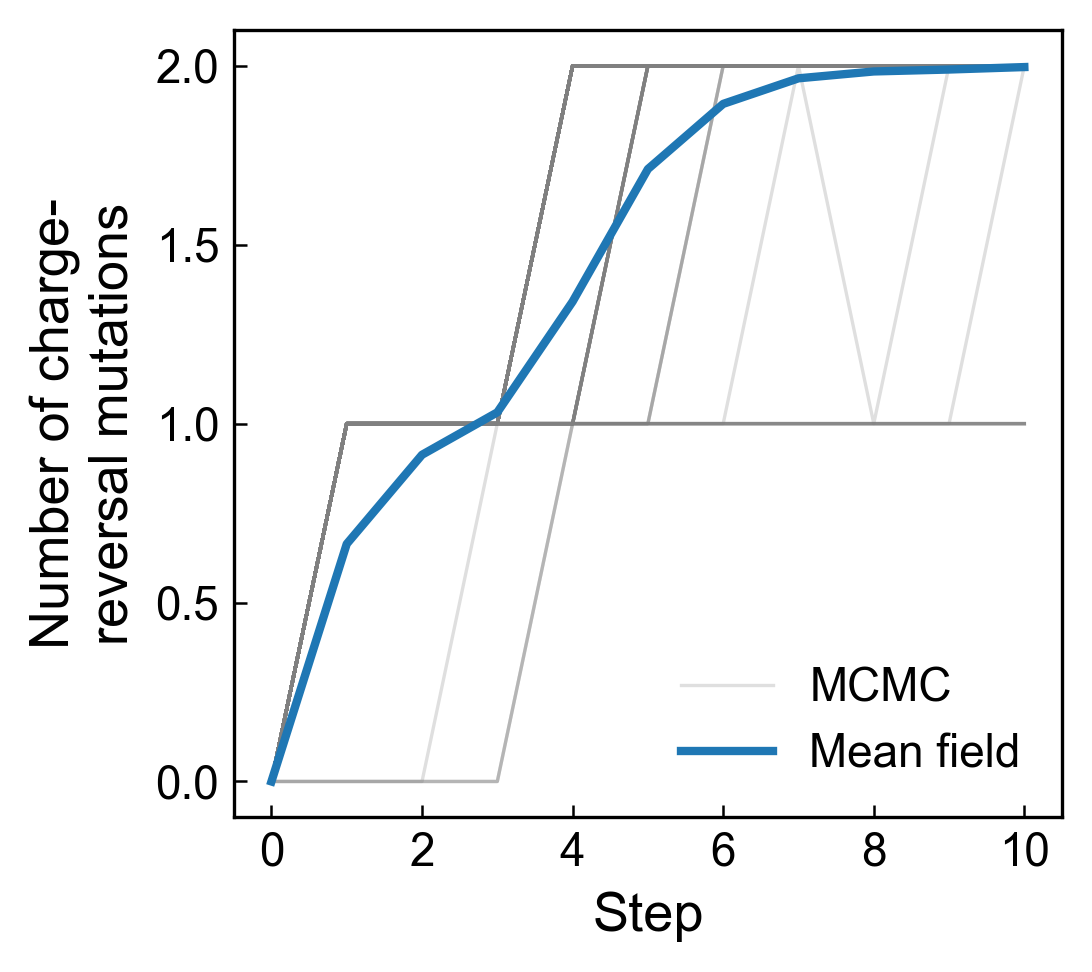

In [22]:

fig, ax = plt.subplots(figsize=(3.8, 3.4))

steps = np.arange(gamma.shape[0])

for i,arr in enumerate(all_ll_biased_rbm):
    if i==0:
        ax.plot(steps, arr, label="MCMC", color='gray', alpha=0.25, lw=0.8)
    else:
        ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)


ax.plot(steps, gamma, label="Mean field", lw=2, color='tab:blue')

ax.set_xlabel("Step")
ax.set_ylabel("Number of charge-\nreversal mutations")

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('black')
    s.set_linewidth(0.8)

ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()

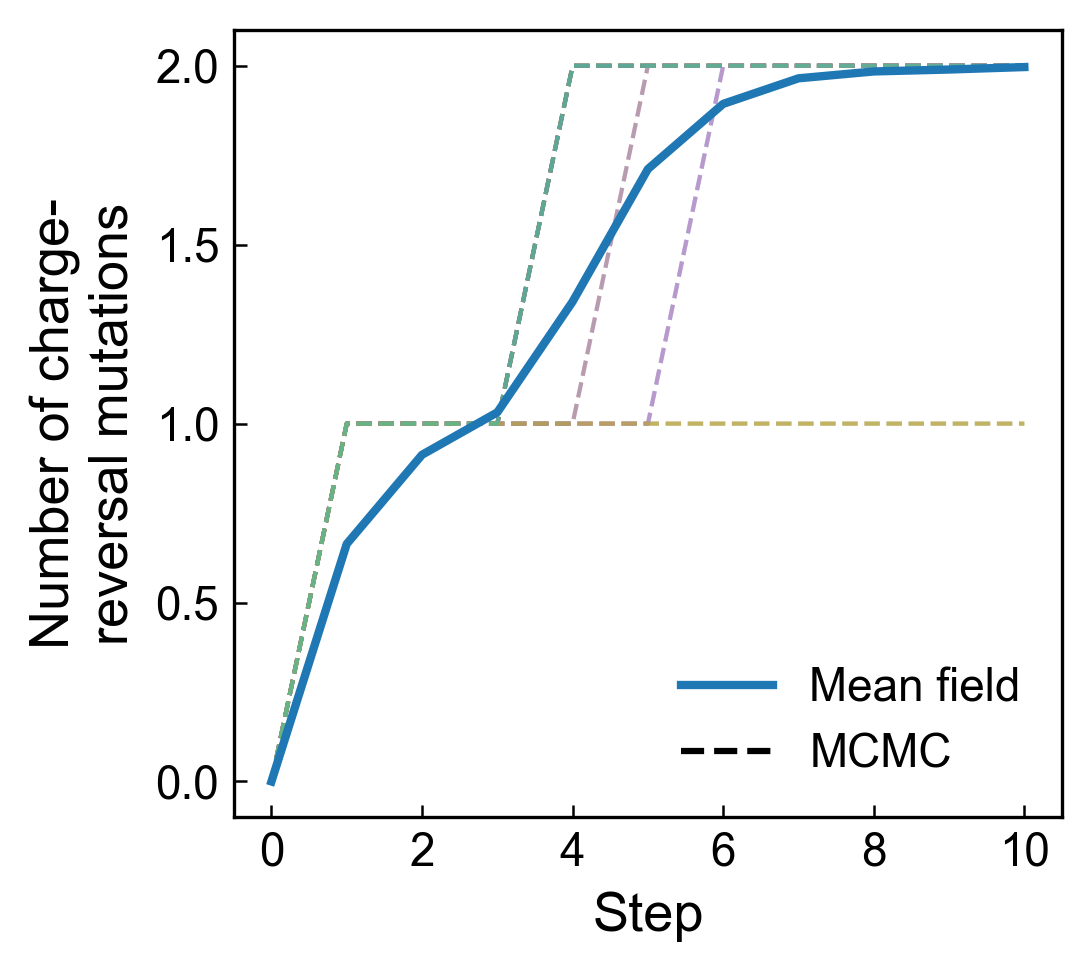

In [23]:


n_to_plot = 15 
total_paths = all_ll_biased_rbm.shape[0]

random_indices = np.random.choice(total_paths, size=n_to_plot, replace=False)


fig, ax = plt.subplots(figsize=(3.8, 3.4))

steps = np.arange(gamma.shape[0])

cmap = plt.colormaps['tab10']
colors = [cmap(i / n_to_plot) for i in range(n_to_plot)]

for i, idx in enumerate(random_indices):
    ax.plot(steps, all_ll_biased_rbm[idx], color=colors[i], alpha=0.5, lw=1.0, ls='--')

ax.plot(steps, gamma, label="Mean field", lw=2, color='tab:blue', ls='-')

ax.plot([], [], color='black', ls='--', label="MCMC")

ax.set_xlabel("Step")
ax.set_ylabel("Number of charge-\nreversal mutations")

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('black')
    s.set_linewidth(0.8)

ax.tick_params(direction='in', length=3, width=0.6)

# 6. Legend and Layout
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()